In [1]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import du processeur de production spécialisé
from tools.OI_class_OP import OI_ProductionProcessor

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
# Cellule 2 : Définition des métadonnées de tags API
tags = [
    {'tag':'WQ33222VA', 'nom':'Ester','info':'Totalisation du Peson Acetate/Propionate' },
    {'tag':'3340_type', 'nom':'A/P','info':'Acetate ou Propionate' },
    {'tag':'CTY_ACV43A_Teneur Vit. A (UV)', 'nom':'Acetate_UV','info':'ACV43A teneur en acetate'},
    {'tag':'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom':'Propionate_UV', 'info':'A3340FGB teneur en propionate'},
    {'tag':'PU3310VA_Sign','nom':'PU3310','info':'signature du PU3310'},
    {'tag':'PU3320VA_Sign','nom':'PU3320','info':'signature du PU3320'},
    {'tag':'PU3340VA_Sign','nom':'PU3340','info':'signature du PU3340'},
    {'tag':'FQ32202VA_UV','nom':'Hexane','info':'VA diluée dans de l\'hexane'},
    {'tag':'CTY_A3230A_Teneur en rétinol', 'nom':'Retinol_UV','info':'A3230A teneur en rétinol lavé'},
    {'tag':'LI33203VA','nom':'R33020','info':'niveau du R33020'},
    {'tag':'LI33218VA','nom':'R33022','info':'niveau du R33022'},
    {'tag':'LI33225VA','nom':'R33061','info':'niveau du R33061'},
    {'tag':'WI33222VA','nom':'R33060','info':'peson du R33060'}
]

In [3]:
# Cellule 3 : Variable Produits unifiée (Acetate & Propionate)
# Plus aucune distinction batch / continu pour le calcul global du stock d'un produit.
produits = [
    {
        'nom': 'Acetate',
        'conso': {
            'value': 'Ester',
            'scale': 1e-9,
            'type':'A/P',
            'uv': ['Acetate_UV', 'Propionate_UV'],
        },
        'stock': [
            # Batchs
            {'pu': 'PU3310', 'in': 540, 'out': 710, 'value': 'Hexane', 'uv': 'Retinol_UV', 'scale': 1/(825 * 100.)},
            {'pu': 'PU3310', 'in': 710, 'out': 2320, 'value': None, 'uv': None, 'scale': 2.71},
            {'pu': 'PU3320', 'in': 430, 'out': 2020, 'value': None, 'uv': None, 'scale': 2.71},
            # Continus
            {'pu': None, 'value': 'R33020', 'min': 14, 'epalage': [[28.62, 21.22, 3.866, -0.0983], [-228.84, 74.557]], 'uv': 'Retinol_UV', 'scale': 1/100., 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': None, 'value': 'R33022', 'min': 14, 'epalage': [[6.25, 5.4525, 0.898, -0.0256], [-35, 97, 16.039]], 'uv': 'Retinol_UV', 'scale': 1/100., 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': None, 'value': 'R33061', 'min': 18, 'epalage': [[0.69, 0.72, 0.296, -0.0059], [-30.03, 5.836]], 'uv': None, 'scale': 0.95 , 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': 'PU3340', 'in': 0, 'out': 710, 'value': 'R33060', 'uv': None, 'scale': 0.95, 'cond': 'A/P', 'val_cond': [1/344, 1/359]}
        ]
    },
]

In [4]:
# Cellule 4 : Initialisation du processeur de production spécialisé
processor = OI_ProductionProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    start = '2026-01-01',
    end = '2026-12-31',
    tags_metadata = tags,
    produits = produits,
    interval = 'PT20M',
    verbose = False
)

In [5]:
# Cellule 5 : Téléchargement et calcul automatique des bilans par produit
processor.merge()
processor.compute_production_balance()

# Visualisation des premières lignes calculées
processor.data.describe()

,Ester,A/P,Acetate_UV,Propionate_UV,PU3310,PU3320,PU3340,Hexane,Retinol_UV,R33020,R33022,R33061,R33060,consommation_Acetate,stock_Acetate,conso_delta_Acetate,delta_stock_Acetate,production_Acetate
count,1.065700e+04,10657.000000,1.065700e+04,1.065700e+04,10654.000000,10655.000000,10653.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000,10657.000000
mean,2.443917e+06,0.078026,2.226097e+06,2.283476e+06,1012.787132,941.467209,461.890331,2564.339081,20.793719,45.552421,4.940741,7.193314,684.201301,495.981349,6.650810,495.981349,0.423398,496.404746
std,1.391678e+05,0.268095,3.902501e+04,4.973453e+04,599.774517,529.705531,111.552321,1862.138373,0.373228,20.353787,2.409374,11.011168,346.073567,311.302992,2.261508,311.302992,2.261508,311.851904
min,2.221310e+06,0.000000,2.078915e+06,2.188000e+06,100.000000,100.000000,313.116667,0.000000,20.000000,-7.918751,-0.695313,-0.337315,6.278194,0.000000,0.724677,0.000000,-5.502735,-1.516407
25%,2.312340e+06,0.000000,2.221983e+06,2.242000e+06,400.000000,400.000000,410.000000,0.000000,20.600000,23.962514,3.445481,2.199220,423.850337,202.180435,5.510769,202.180435,-0.716643,202.193960
50%,2.426310e+06,0.000000,2.230864e+06,2.314000e+06,1308.912500,1113.683333,410.000000,3932.160000,20.800000,44.816790,5.937500,2.907840,681.342250,454.823979,7.027294,454.823979,0.799881,457.653540
75%,2.567640e+06,0.000000,2.245768e+06,2.314000e+06,1310.000000,1297.500000,410.000000,4037.700000,21.200000,64.381482,6.485698,4.050865,941.549975,772.712698,8.160765,772.712698,1.933352,774.395624
max,2.700790e+06,1.000000,2.325113e+06,2.626000e+06,2320.033333,2249.987500,810.000000,4836.070000,21.200000,91.504357,12.239069,68.457970,1321.036235,1072.961445,12.528535,1072.961445,6.301123,1072.544343


In [6]:
# Cellule 6 : Calcul du bilan mensuel général (ex: Mai 2026 à date)
bilan = processor.calcul_cumul_mensuel(mois=5, std=2)

____________________________________________________________
BILAN MENSUEL - MAI 2026 (À date (En cours))
Période : du 01/05/2026 à 02:00 au 29/05/2026 à 04:00
____________________________________________________________
PRODUIT : ACETATE
------------------------------------------------------------
  Consommation (Ester)   : 241.6247
  Variation de Stock     : -2.3986
  Production             : 239.2261
____________________________________________________________
____________________________________________________________


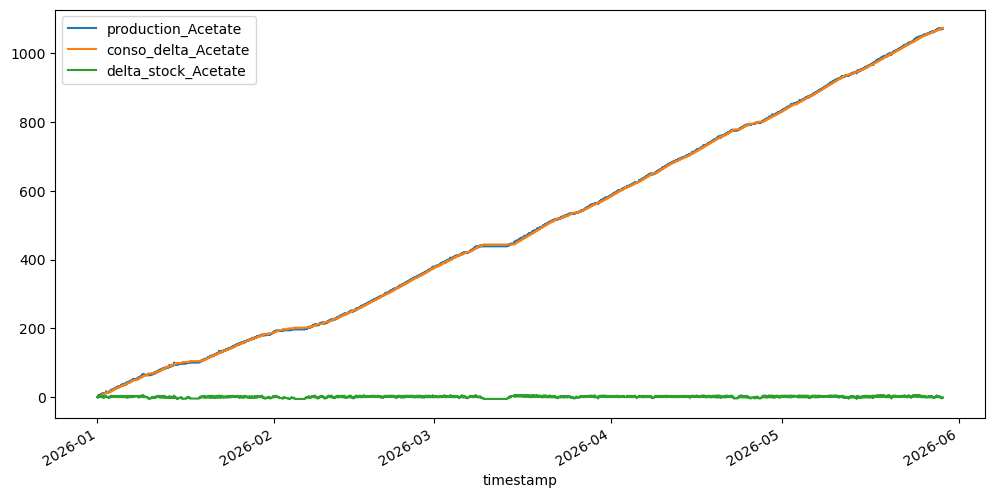

In [7]:
# Cellule 7 : Graphique temporel du bilan d'Acétate
processor.data.plot(y=['production_Acetate', 'conso_delta_Acetate', 'delta_stock_Acetate'], figsize=(12,6));